# 03c — Epoch-calibrated classification

Main question:

> If we split each recording into 30-second epochs, can we classify each epoch as Eyes Closed (EC) or Eyes Open (EO) using a participant-specific alpha threshold?

This is different from both previous notebooks:

- `03a` used full recordings and paired EC–EO comparisons.
- `03b` classified full recordings from unseen participants.
- `03c` classifies shorter 30-second epochs using participant-specific calibration.

The simple rule here is:

> For each participant, calculate the median alpha power across that participant's retained epochs. Epochs above the median are classified as EC; epochs below the median are classified as EO.

We compare:

1. Oz alpha
2. Occipital alpha
3. Posterior alpha


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

warnings.filterwarnings("ignore")

# Change this only if the project folder moves.
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")

DATA_DIR = PROJECT_ROOT / "data_processed"
RESULTS_DIR = DATA_DIR / "model_results"
FIGURES_DIR = PROJECT_ROOT / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

EPOCH_FEATURES_FILE = DATA_DIR / "epoch_features.csv"
PAIRED_RESULTS_FILE = RESULTS_DIR / "paired_results.csv"
SUBJECT_RESULTS_FILE = RESULTS_DIR / "subject_independent_results.csv"

EPOCH_RESULTS_FILE = RESULTS_DIR / "epoch_calibrated_results.csv"
EPOCH_PREDICTIONS_FILE = RESULTS_DIR / "epoch_calibrated_predictions.csv"

epoch_features = pd.read_csv(EPOCH_FEATURES_FILE)

print("Epoch features:", epoch_features.shape)
epoch_features.head()


Epoch features: (7341, 57)


,recording_id,participant_id,pair_id,condition,age,sex,handedness,epoch_index,epoch_start_sec,epoch_retained,...,ch_PO10_alpha_log,ch_P5_alpha_log,ch_P1_alpha_log,ch_P2_alpha_log,ch_P6_alpha_log,ch_PO7_alpha_log,ch_PO3_alpha_log,ch_POz_alpha_log,ch_PO4_alpha_log,ch_PO8_alpha_log
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,0,0.0,True,...,-9.726599,-10.196395,-10.576109,-10.492524,-10.145058,-9.665502,-10.082306,-10.265752,-10.096952,-9.718324
1,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,1,30.0,True,...,-9.928387,-10.338972,-10.593724,-10.418874,-10.225728,-9.820944,-10.200900,-10.327990,-10.170780,-9.892246
2,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,2,60.0,True,...,-9.929616,-10.352066,-10.569878,-10.389602,-10.207929,-9.847308,-10.216236,-10.308197,-10.145261,-9.894123
3,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,3,90.0,True,...,-9.864179,-10.300227,-10.478005,-10.269003,-10.116495,-9.803728,-10.114147,-10.156939,-10.043688,-9.821964
4,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,EC,60,F,right,4,120.0,True,...,-10.048527,-10.301327,-10.501133,-10.319291,-10.187665,-9.833197,-10.158857,-10.247084,-10.105013,-9.962354


## 1. Define the epoch analysis sample

We use retained epochs from EO and EC recordings only.

Each epoch is one sample. The true labels are:

- `EO = 0`
- `EC = 1`


In [2]:
epoch_df = epoch_features.copy()

# Keep only retained epochs if the column exists.
if "epoch_include" in epoch_df.columns:
    epoch_df = epoch_df[epoch_df["epoch_include"].astype(bool)].copy()
elif "include" in epoch_df.columns:
    epoch_df = epoch_df[epoch_df["include"].astype(bool)].copy()

epoch_df = epoch_df[epoch_df["condition"].isin(["EO", "EC"])].copy()
epoch_df["y"] = epoch_df["condition"].map({"EO": 0, "EC": 1}).astype(int)

print("Included epochs:", epoch_df.shape)
print("Unique participants:", epoch_df["participant_id"].nunique())
print("Unique recordings:", epoch_df["recording_id"].nunique())

display(epoch_df["condition"].value_counts())
display(epoch_df.groupby("condition").size().rename("n_epochs"))
display(epoch_df.groupby("participant_id").size().describe())


Included epochs: (7341, 58)
Unique participants: 608
Unique recordings: 1216


condition
EC    3677
EO    3664
Name: count, dtype: int64

condition
EC    3677
EO    3664
Name: n_epochs, dtype: int64

count    608.000000
mean      12.074013
std        0.371269
min        8.000000
25%       12.000000
50%       12.000000
75%       12.000000
max       15.000000
dtype: float64

## 2. Helper functions

The participant-specific median threshold is calculated separately for each participant and feature.

For example, for posterior alpha:

1. Take all retained EO and EC epochs from one participant.
2. Calculate the median posterior alpha value.
3. Predict epochs above the median as EC.
4. Predict epochs below or equal to the median as EO.

This is participant-calibrated because the threshold is personal to each participant.


In [3]:
def participant_bootstrap_accuracy_ci(predictions, n_boot=5000, seed=42):
    """Bootstrap a 95% CI for epoch accuracy by resampling participants."""
    rng = np.random.default_rng(seed)

    participant_ids = predictions["participant_id"].drop_duplicates().values
    participant_to_rows = {
        pid: predictions.index[predictions["participant_id"] == pid].to_numpy()
        for pid in participant_ids
    }

    boot = []

    for _ in range(n_boot):
        sampled_pids = rng.choice(participant_ids, size=len(participant_ids), replace=True)
        sampled_indices = np.concatenate([participant_to_rows[pid] for pid in sampled_pids])
        sampled = predictions.loc[sampled_indices]
        boot.append((sampled["y_true"] == sampled["y_pred"]).mean())

    return np.percentile(boot, [2.5, 97.5])


def run_epoch_median_rule(df, feature_col, model_name):
    """Run participant-specific median threshold classification."""
    d = df.dropna(subset=[feature_col]).copy()

    # Median threshold per participant.
    thresholds = (
        d.groupby("participant_id")[feature_col]
        .median()
        .rename("participant_threshold")
    )

    d = d.merge(
        thresholds,
        on="participant_id",
        how="left",
        validate="many_to_one",
    )

    d["y_true"] = d["y"].astype(int)

    # Above participant median = predicted EC.
    d["y_pred"] = (d[feature_col] > d["participant_threshold"]).astype(int)

    d["correct"] = d["y_true"] == d["y_pred"]

    acc = accuracy_score(d["y_true"], d["y_pred"])
    bal_acc = balanced_accuracy_score(d["y_true"], d["y_pred"])
    ci_low, ci_high = participant_bootstrap_accuracy_ci(d)

    result = {
        "setting": "epoch_calibrated",
        "model_name": model_name,
        "feature_set": feature_col,
        "n_epochs": len(d),
        "n_participants": d["participant_id"].nunique(),
        "n_recordings": d["recording_id"].nunique(),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "ci_lower": ci_low,
        "ci_upper": ci_high,
        "notes": "Participant-specific median threshold. Epochs above median predicted as EC.",
    }

    predictions = d[[
        "participant_id",
        "recording_id",
        "condition",
        "epoch_index",
        feature_col,
        "participant_threshold",
        "y_true",
        "y_pred",
        "correct",
    ]].copy()

    predictions["setting"] = "epoch_calibrated"
    predictions["model_name"] = model_name
    predictions = predictions.rename(columns={feature_col: "feature_value"})

    return result, predictions


def summarize_by_participant(predictions):
    """Calculate participant-level accuracy summaries."""
    return (
        predictions
        .groupby(["model_name", "participant_id"])
        .agg(
            participant_accuracy=("correct", "mean"),
            n_epochs=("correct", "size"),
        )
        .reset_index()
    )


## 3. Run participant-calibrated median-threshold rules

We compare the same three spatial levels:

1. Oz only
2. Occipital channels
3. Posterior channels


In [4]:
epoch_feature_sets = {
    "epoch_median_oz_alpha": "oz_alpha_log",
    "epoch_median_occipital_alpha": "occipital_alpha_log",
    "epoch_median_posterior_alpha": "posterior_alpha_log",
}

# Keep only features that exist.
epoch_feature_sets = {
    name: col
    for name, col in epoch_feature_sets.items()
    if col in epoch_df.columns
}

all_results = []
all_predictions = []

for model_name, feature_col in epoch_feature_sets.items():
    result, predictions = run_epoch_median_rule(epoch_df, feature_col, model_name)
    all_results.append(result)
    all_predictions.append(predictions)

epoch_results = pd.DataFrame(all_results)
epoch_predictions = pd.concat(all_predictions, ignore_index=True)

display(epoch_results[[
    "model_name",
    "n_epochs",
    "n_participants",
    "n_recordings",
    "accuracy",
    "balanced_accuracy",
    "ci_lower",
    "ci_upper",
]])


,model_name,n_epochs,n_participants,n_recordings,accuracy,balanced_accuracy,ci_lower,ci_upper
0,epoch_median_oz_alpha,6988,607,1208,0.875787,0.875965,0.858638,0.892273
1,epoch_median_occipital_alpha,6988,607,1208,0.884659,0.884839,0.867979,0.900683
2,epoch_median_posterior_alpha,6988,607,1208,0.882370,0.882549,0.866089,0.898215


## 4. Confusion matrices

Rows are the true condition and columns are the predicted condition.


In [5]:
for model_name in epoch_results["model_name"]:
    pred = epoch_predictions[epoch_predictions["model_name"] == model_name]

    cm = confusion_matrix(pred["y_true"], pred["y_pred"], labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=["true_EO", "true_EC"],
        columns=["pred_EO", "pred_EC"],
    )

    print("\n", model_name)
    display(cm_df)



 epoch_median_oz_alpha


,pred_EO,pred_EC
true_EO,3067,381
true_EC,487,3053



 epoch_median_occipital_alpha


,pred_EO,pred_EC
true_EO,3098,350
true_EC,456,3084



 epoch_median_posterior_alpha


,pred_EO,pred_EC
true_EO,3090,358
true_EC,464,3076


## 5. Participant-level accuracy

This checks whether the result is driven by a few participants or is broadly consistent across participants.


,count,mean,std,min,25%,50%,75%,max
model_name,,,,,,,,
epoch_median_occipital_alpha,607.0,0.879750,0.210270,0.0,0.833333,1.0,1.0,1.0
epoch_median_oz_alpha,607.0,0.871067,0.213919,0.0,0.833333,1.0,1.0,1.0
epoch_median_posterior_alpha,607.0,0.877588,0.206104,0.0,0.833333,1.0,1.0,1.0


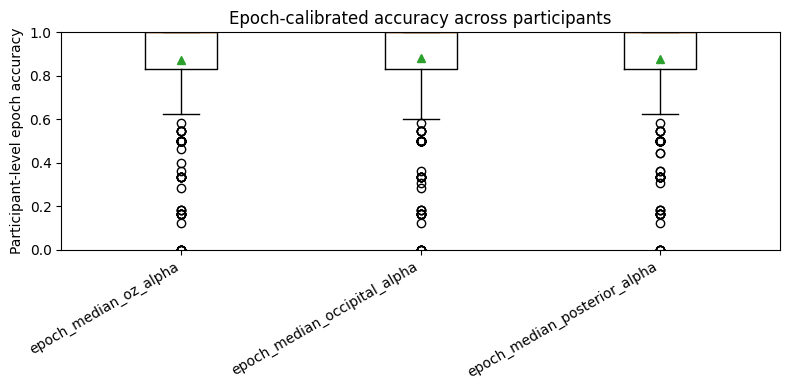

In [6]:
participant_summary = summarize_by_participant(epoch_predictions)

display(
    participant_summary
    .groupby("model_name")["participant_accuracy"]
    .describe()
)

plt.figure(figsize=(8, 4))

plot_data = [
    participant_summary.loc[
        participant_summary["model_name"] == model_name,
        "participant_accuracy"
    ].dropna().values
    for model_name in epoch_results["model_name"]
]

plt.boxplot(plot_data, labels=epoch_results["model_name"], showmeans=True)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Participant-level epoch accuracy")
plt.title("Epoch-calibrated accuracy across participants")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "epoch_calibrated_participant_accuracy_boxplot.png", dpi=300)
plt.show()


## 6. Save epoch-calibrated results

In [7]:
epoch_results.to_csv(EPOCH_RESULTS_FILE, index=False)
epoch_predictions.to_csv(EPOCH_PREDICTIONS_FILE, index=False)

print("Saved:", EPOCH_RESULTS_FILE)
print("Saved:", EPOCH_PREDICTIONS_FILE)


Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\epoch_calibrated_results.csv
Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\model_results\epoch_calibrated_predictions.csv


## 7. Figure: epoch-calibrated model accuracy

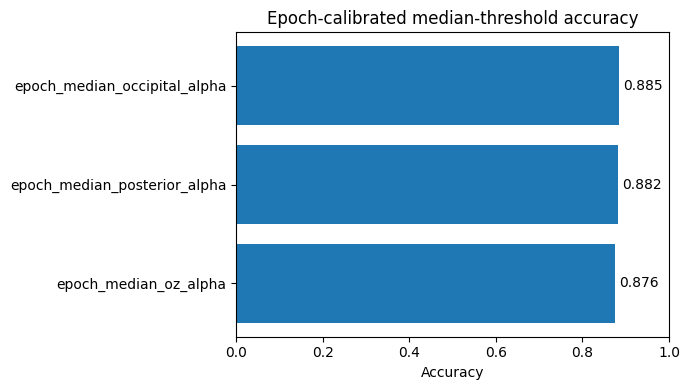

In [8]:
plot_results = epoch_results.copy()
plot_results = plot_results.sort_values("accuracy", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(plot_results["model_name"], plot_results["accuracy"])
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Epoch-calibrated median-threshold accuracy")

for i, (_, row) in enumerate(plot_results.iterrows()):
    plt.text(
        row["accuracy"] + 0.01,
        i,
        f"{row['accuracy']:.3f}",
        va="center",
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "epoch_calibrated_model_accuracy.png", dpi=300)
plt.show()


## 8. Compare all three settings

This comparison combines:

1. Paired full-recording classification (`03a`)
2. Subject-independent full-recording classification (`03b`)
3. Epoch-calibrated classification (`03c`)


,setting,model,accuracy
15,Epoch-calibrated,Occipital alpha,0.884659
14,Epoch-calibrated,Oz alpha,0.875787
16,Epoch-calibrated,Posterior alpha,0.882370
6,Paired full recording,Combined,0.967851
5,Paired full recording,FOOOF,0.945854
1,Paired full recording,Occipital alpha,0.944162
0,Paired full recording,Oz alpha,0.934010
2,Paired full recording,Posterior alpha,0.937394
3,Paired full recording,Posterior channels,0.942470
4,Paired full recording,Welch multiband,0.974619


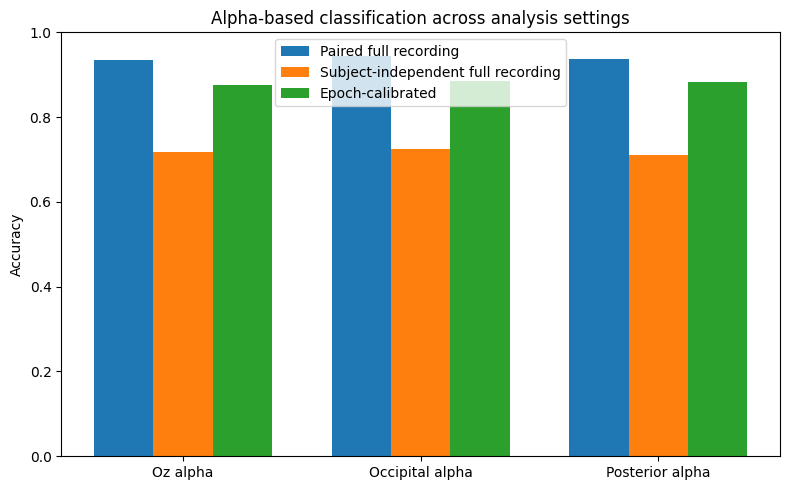

In [9]:
comparison_rows = []

if PAIRED_RESULTS_FILE.exists():
    paired_results = pd.read_csv(PAIRED_RESULTS_FILE)

    paired_map = {
        "simple_rule_oz_alpha": "Oz alpha",
        "simple_rule_occipital_alpha": "Occipital alpha",
        "simple_rule_posterior_alpha": "Posterior alpha",
        "paired_lr_posterior_channels_L2": "Posterior channels",
        "paired_lr_welch_multiband_L2": "Welch multiband",
        "paired_lr_fooof_L2": "FOOOF",
        "paired_lr_combined_L2": "Combined",
    }

    tmp = paired_results.copy()
    tmp["display_model"] = tmp["model_name"].map(paired_map)
    tmp = tmp.dropna(subset=["display_model"])

    for _, row in tmp.iterrows():
        comparison_rows.append({
            "setting": "Paired full recording",
            "model": row["display_model"],
            "accuracy": row["accuracy"],
        })

if SUBJECT_RESULTS_FILE.exists():
    subject_results = pd.read_csv(SUBJECT_RESULTS_FILE)

    subject_map = {
        "subject_lr_oz_alpha_L2": "Oz alpha",
        "subject_lr_occipital_alpha_L2": "Occipital alpha",
        "subject_lr_posterior_alpha_L2": "Posterior alpha",
        "subject_lr_posterior_channels_L2": "Posterior channels",
        "subject_lr_welch_multiband_L2": "Welch multiband",
        "subject_lr_fooof_L2": "FOOOF",
        "subject_lr_combined_L2": "Combined",
    }

    tmp = subject_results.copy()
    tmp["display_model"] = tmp["model_name"].map(subject_map)
    tmp = tmp.dropna(subset=["display_model"])

    for _, row in tmp.iterrows():
        comparison_rows.append({
            "setting": "Subject-independent full recording",
            "model": row["display_model"],
            "accuracy": row["accuracy"],
        })

epoch_map = {
    "epoch_median_oz_alpha": "Oz alpha",
    "epoch_median_occipital_alpha": "Occipital alpha",
    "epoch_median_posterior_alpha": "Posterior alpha",
}

tmp = epoch_results.copy()
tmp["display_model"] = tmp["model_name"].map(epoch_map)
tmp = tmp.dropna(subset=["display_model"])

for _, row in tmp.iterrows():
    comparison_rows.append({
        "setting": "Epoch-calibrated",
        "model": row["display_model"],
        "accuracy": row["accuracy"],
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(["setting", "model"]))

# Plot only the alpha models common to all three settings.
common_models = ["Oz alpha", "Occipital alpha", "Posterior alpha"]
settings = [
    "Paired full recording",
    "Subject-independent full recording",
    "Epoch-calibrated",
]

plot_df = comparison_df[comparison_df["model"].isin(common_models)].copy()

x = np.arange(len(common_models))
width = 0.25

plt.figure(figsize=(8, 5))

for i, setting in enumerate(settings):
    vals = []
    for model in common_models:
        v = plot_df[
            (plot_df["setting"] == setting)
            & (plot_df["model"] == model)
        ]["accuracy"]

        vals.append(v.iloc[0] if len(v) else np.nan)

    plt.bar(x + (i - 1) * width, vals, width, label=setting)

plt.xticks(x, common_models)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Alpha-based classification across analysis settings")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "alpha_accuracy_across_settings.png", dpi=300)
plt.show()
